In [1]:
! pip install  --upgrade scikit-learn

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
print(load_diabetes()["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X, y = load_diabetes(return_X_y=True)

In [5]:

from matplotlib import pyplot as plt
import pandas as pd

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [7]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=1))
])
pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('model', KNeighborsRegressor(n_neighbors=1))],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(n_neighbors=1),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 1,
 'model__p': 2,
 'model__weights': 'uniform'}

In [8]:
mod = GridSearchCV(estimator=pipe, param_grid={"model__n_neighbors": list(range(1,10))}, cv=3)

In [9]:
mod.fit(X,y)

,estimator,Pipeline(step...eighbors=1))])
,param_grid,"{'model__n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [10]:
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004782,0.003246,0.003812,0.000602,1,{'model__n_neighbors': 1},0.105976,0.124092,-0.158523,0.023849,0.129168,9
1,0.002030,0.000427,0.003365,0.000491,2,{'model__n_neighbors': 2},0.268889,0.339379,0.264563,0.290944,0.034295,8
2,0.003459,0.001845,0.003448,0.001130,3,{'model__n_neighbors': 3},0.333057,0.382744,0.356899,0.357567,0.020290,7
3,0.002334,0.000471,0.003725,0.001780,4,{'model__n_neighbors': 4},0.342407,0.404701,0.409910,0.385673,0.030668,5
4,0.002497,0.000407,0.006455,0.002892,5,{'model__n_neighbors': 5},0.358865,0.377198,0.412549,0.382871,0.022280,6
5,0.004447,0.001498,0.006670,0.002051,6,{'model__n_neighbors': 6},0.372665,0.389923,0.436389,0.399659,0.026911,4
6,0.004729,0.003119,0.005333,0.000471,7,{'model__n_neighbors': 7},0.412584,0.393681,0.446147,0.417471,0.021696,3
7,0.004099,0.000831,0.009043,0.003408,8,{'model__n_neighbors': 8},0.414478,0.409779,0.485850,0.436702,0.034806,2
8,0.006381,0.002927,0.005036,0.001441,9,{'model__n_neighbors': 9},0.414191,0.412035,0.528462,0.451563,0.054383,1


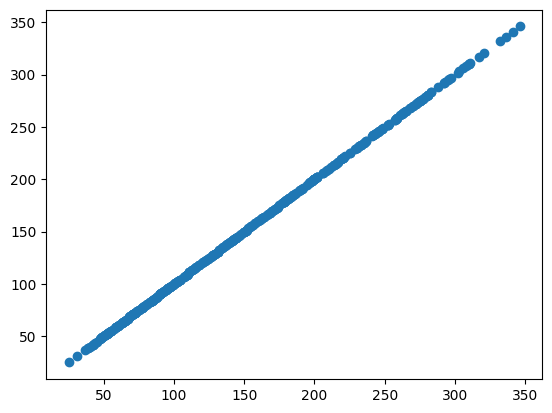

In [11]:
pipe.fit(X,y)
pred = pipe.predict(X)
plt.scatter(pred,y)